
# Basic Machine Learning - I: Practical Notebook

This notebook contains all the hands-on practicals for the **Basic Machine Learning - I** session.

We use two real, well-known datasets that load directly through `seaborn` (no manual download needed):

- **Titanic dataset** — passenger records, used for **Data Preprocessing**, **Logistic Regression**, **KNN**, and **SVM**
- **Auto MPG dataset** — car specifications, used for **Linear Regression**

For Linear Regression, Logistic Regression, KNN, and SVM, we start with a small, easy-to-follow toy
example before moving to the real dataset — so the mechanics of each algorithm are clear before the
data gets more complex.

**A note on `Pipeline`:** scikit-learn has a `Pipeline` class that bundles scaling and modeling into
one object. We deliberately do **not** use it in the main flow below — every step (scale, fit,
predict) is written out separately so it is easy to see exactly what is happening at each stage. A
commented-out `Pipeline` version is included at the end of a couple of sections, in case you want to
show it as a "here's the shortcut" moment once the manual version is clear.

## Setup: Importing the Libraries We Need

- `numpy` and `pandas` for handling data
- `matplotlib` and `seaborn` for visualization and for loading our two datasets
- `scikit-learn` for preprocessing, models, and evaluation metrics
- `statsmodels` for a proper feature-weight significance table (p-values) in Linear Regression
- `joblib` for saving trained models to disk

In [1]:
# Core data handling libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing tools
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Models used across this notebook
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.inspection import permutation_importance

# For feature-weight p-values
import statsmodels.api as sm

# Saving trained models
import joblib
import os

# Keep plots looking clean and consistent
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

# Fix the random seed so results are the same every time we run this notebook
RANDOM_STATE = 42

# Folder where trained models are saved
os.makedirs("models", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


---

## Practical 1: Data Preprocessing (Titanic Dataset)

Each row is a Titanic passenger. The goal (used later, in Practicals 3-5) is to predict whether a
passenger survived. Here, we focus purely on getting the data ready for modeling.

### 🚢 Titanic Dataset - Feature Description

The Titanic dataset is one of the most popular datasets used for learning **Data Science** and **Machine Learning**. It contains information about passengers aboard the RMS Titanic and whether they survived the disaster.

| Feature | Description | Example |
|---------|-------------|---------|
| **survived** | Survival status (Target Variable). **0 = No**, **1 = Yes** | 1 |
| **pclass** | Passenger ticket class. **1 = First**, **2 = Second**, **3 = Third** | 3 |
| **sex** | Passenger gender | Male, Female |
| **age** | Passenger age in years | 22 |
| **sibsp** | Number of siblings or spouses aboard | 1 |
| **parch** | Number of parents or children aboard | 0 |
| **fare** | Ticket fare paid (British Pounds) | 7.25 |
| **embarked** | Port where the passenger boarded the ship (**C = Cherbourg, Q = Queenstown, S = Southampton**) | S |
| **class** | Passenger class (categorical version of `pclass`) | First, Second, Third |
| **who** | Passenger category based on age and gender | Man, Woman, Child |
| **adult_male** | Whether the passenger is an adult male (**True/False**) | True |
| **deck** | Deck where the cabin was located (A–G). Missing values indicate unknown deck. | C |
| **embark_town** | Full name of the embarkation town | Southampton |
| **alive** | Survival status in text format (**Yes/No**) | Yes |
| **alone** | Whether the passenger was traveling alone (**True/False**) | False |


In [2]:
# Load the Titanic dataset directly from seaborn's built-in dataset repository.
titanic_df = sns.load_dataset("titanic")

print("Shape:", titanic_df.shape)
titanic_df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Keep only the columns relevant to prediction.
# "class", "who", "adult_male", "embark_town", "alive", "alone" all duplicate information
# already captured by "pclass", "age", "sex", "embarked", and "survived".
# "deck" is dropped separately because it is missing for most passengers.

titanic_df = titanic_df[
    ["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
].copy()

titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


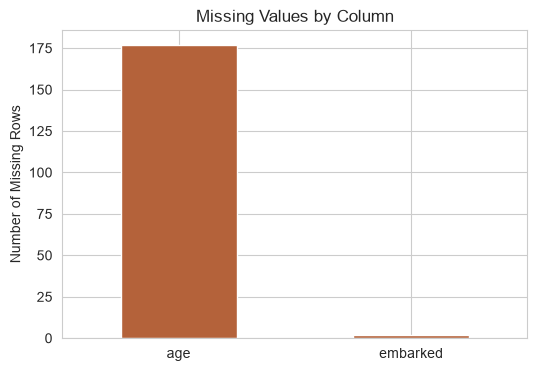

age         177
embarked      2
dtype: int64


In [4]:
# Step 1: Missing value check.

missing_counts = titanic_df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(6, 4))
missing_counts.plot(kind="bar", color="#B4623A")
plt.title("Missing Values by Column")
plt.ylabel("Number of Missing Rows")
plt.xticks(rotation=0)
plt.show()

print(missing_counts)

In [5]:
# Step 2: Handle missing values.
# - "age" is numeric with a moderate number of gaps: fill with the median.
# - "embarked" is categorical with just 2 missing rows: fill with the most common port.

titanic_df["age"] = titanic_df["age"].fillna(titanic_df["age"].median())
titanic_df["embarked"] = titanic_df["embarked"].fillna(titanic_df["embarked"].mode()[0])

print("Remaining missing values:", titanic_df.isnull().sum().sum())

Remaining missing values: 0


In [6]:
# Step 3: Categorical to numerical.
# "sex" has two categories, so a simple 0/1 mapping is enough.
# "embarked" has three categories with no natural order, so we one-hot encode it.

titanic_df["sex"] = titanic_df["sex"].map({"male": 0, "female": 1})
titanic_df = pd.get_dummies(titanic_df, columns=["embarked"], drop_first=True)

# Convert the new True/False dummy columns to 0/1 for clarity.
dummy_cols = [c for c in titanic_df.columns if c.startswith("embarked_")]
titanic_df[dummy_cols] = titanic_df[dummy_cols].astype(int)

titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


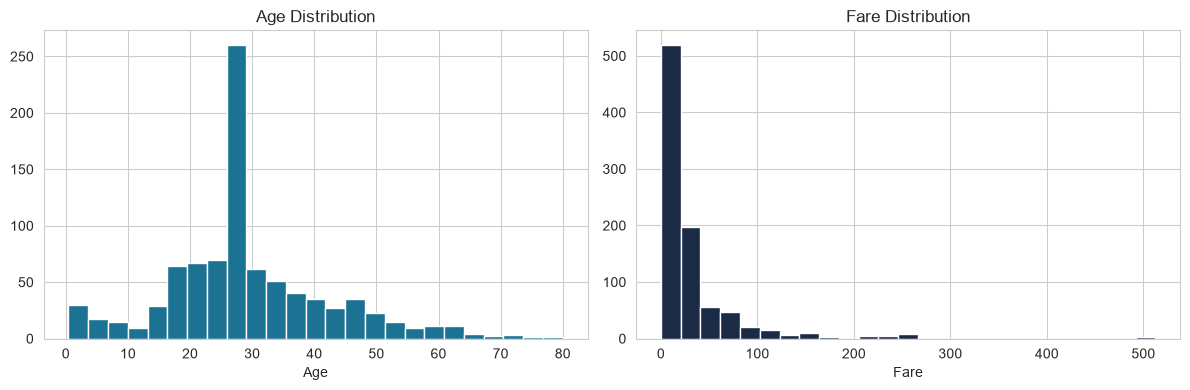

In [7]:
# Step 4: Column-wise EDA.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(titanic_df["age"], bins=25, color="#1C7293", edgecolor="white")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[1].hist(titanic_df["fare"], bins=25, color="#1B2A45", edgecolor="white")
axes[1].set_title("Fare Distribution")
axes[1].set_xlabel("Fare")
plt.tight_layout()
plt.show()

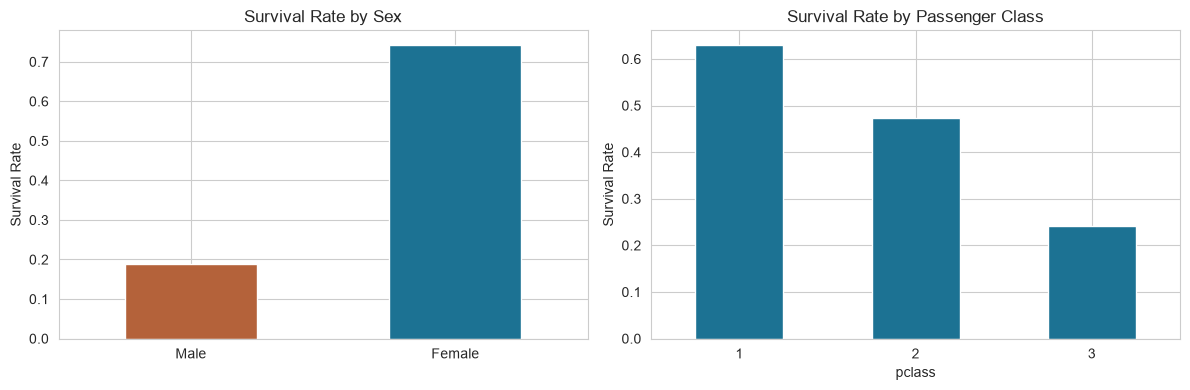

In [8]:
# Survival rate by sex and by passenger class.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

survival_by_sex = titanic_df.groupby("sex")["survived"].mean()
survival_by_sex.index = ["Male", "Female"]
survival_by_sex.plot(kind="bar", ax=axes[0], color=["#B4623A", "#1C7293"])
axes[0].set_title("Survival Rate by Sex")
axes[0].set_ylabel("Survival Rate")
axes[0].tick_params(axis="x", rotation=0)

survival_by_class = titanic_df.groupby("pclass")["survived"].mean()
survival_by_class.plot(kind="bar", ax=axes[1], color="#1C7293")
axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_ylabel("Survival Rate")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

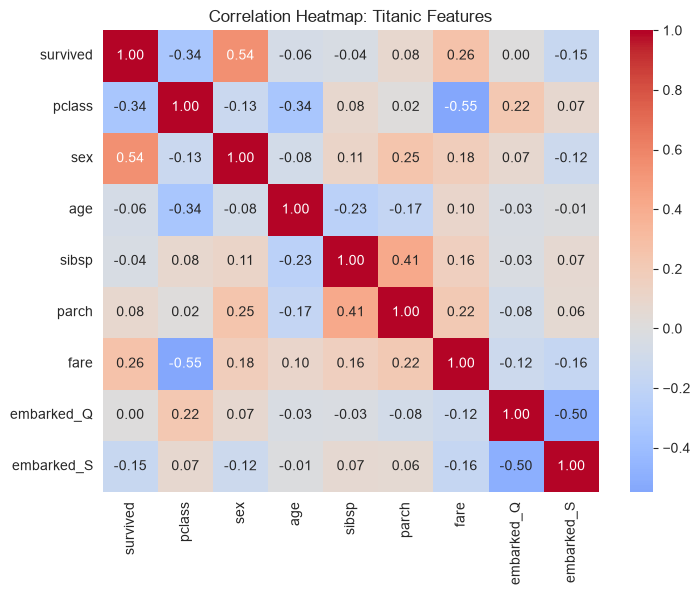

In [9]:
# Correlation heatmap across all prepared features.

plt.figure(figsize=(8, 6))
sns.heatmap(titanic_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Titanic Features")
plt.show()

In [10]:
# Step 5: Standardization.
# We scale "age" and "fare" since they are on very different numeric ranges from
# the rest of the (mostly 0/1) columns.
#
# Note: for simplicity in this walkthrough, we fit the scaler before splitting into
# train and test. In practice, many practitioners fit the scaler AFTER splitting
# (on the training data only) to avoid any information from the test set leaking in.
# We use the split-first approach in Practical 2 for exactly that reason.

scaler_titanic = StandardScaler()
titanic_df[["age", "fare"]] = scaler_titanic.fit_transform(titanic_df[["age", "fare"]])

titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,-0.565736,1,0,-0.502445,0,1
1,1,1,1,0.663861,1,0,0.786845,0,0
2,1,3,1,-0.258337,0,0,-0.488854,0,1
3,1,1,1,0.433312,1,0,0.420730,0,1
4,0,3,0,0.433312,0,0,-0.486337,0,1


In [11]:
# Step 6: Train-test split.
# stratify=y keeps the same survived/did-not-survive proportion in both parts.

X_titanic = titanic_df.drop(columns=["survived"])
y_titanic = titanic_df["survived"]

X_titanic_train, X_titanic_test, y_titanic_train, y_titanic_test = train_test_split(
    X_titanic, y_titanic, test_size=0.25, random_state=RANDOM_STATE, stratify=y_titanic
)

print("Training passengers:", X_titanic_train.shape[0])
print("Testing passengers:", X_titanic_test.shape[0])
print("Features:", list(X_titanic.columns))

Training passengers: 668
Testing passengers: 223
Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']


This prepared, split Titanic data (`X_titanic_train`, `X_titanic_test`, `y_titanic_train`,
`y_titanic_test`) is reused directly in Practicals 3, 4, and 5 — no need to repeat these steps.


---

## Practical 2: Linear Regression

### Step A: A Simple Toy Example First

Before touching a real dataset, let's build the simplest possible Linear Regression: a case with no
noise at all, where we know the true relationship in advance. This lets us confirm, by hand, that the
model recovers exactly what we expect.

The true relationship here is $y = 3x_0 + 5x_1 + 10$.

In [12]:
import numpy as np
from sklearn.linear_model import LinearRegression

# True relationship: y = 3*x0 + 5*x1 + 10 (no noise, so the fit will be perfect)
X_toy = np.array([
    [0, 1],
    [1, 0],
    [1, 1],
    [2, 1],
    [1, 2],
    [2, 2],
    [3, 1],
])
y_toy = np.dot(X_toy, np.array([3, 5])) + 10

reg_toy = LinearRegression().fit(X_toy, y_toy)

print("R-squared score:", reg_toy.score(X_toy, y_toy))
print("Learned coefficients:", reg_toy.coef_)
print("Learned intercept:", reg_toy.intercept_)
print("Prediction for [4, 2]:", reg_toy.predict(np.array([[4, 2]])))
print()
print("Expected: coefficients [3, 5], intercept 10, prediction for [4,2] = 3*4 + 5*2 + 10 = 32")

R-squared score: 1.0
Learned coefficients: [3. 5.]
Learned intercept: 10.0
Prediction for [4, 2]: [32.]

Expected: coefficients [3, 5], intercept 10, prediction for [4,2] = 3*4 + 5*2 + 10 = 32


The model recovered the exact relationship we built into the data — a perfect R-squared of 1.0.
Real data is never this clean, but this confirms the mechanics work exactly as expected before we
move to something messier.

### Step B: The Real Practical — Auto MPG Dataset

Now we predict a car's fuel efficiency (miles per gallon) from its specifications.

### 🚗 MPG (Miles Per Gallon) Dataset - Feature Description

The **MPG (Auto MPG)** dataset is a popular dataset used for learning **Regression**, **Exploratory Data Analysis (EDA)**, and **Feature Engineering**. It contains specifications of automobiles and their fuel efficiency.

The goal is to predict a car's **fuel efficiency (MPG)** based on its engine and vehicle characteristics.

| Feature | Description | Example |
|---------|-------------|---------|
| **mpg** | Miles Per Gallon (Fuel Efficiency). Indicates how many miles a car can travel using one gallon of fuel. **Target Variable** | 18.0 |
| **cylinders** | Number of engine cylinders | 4, 6, 8 |
| **displacement** | Engine displacement (cubic inches). Larger values generally indicate larger engines. | 307.0 |
| **horsepower** | Engine power (Horsepower - HP) | 130 |
| **weight** | Vehicle weight (pounds) | 3504 |
| **acceleration** | Time (seconds) required to accelerate from **0 to 60 mph** | 12.0 |
| **model_year** | Manufacturing model year (represented by the last two digits) | 70 (1970) |
| **origin** | Country where the car was manufactured (**1 = USA, 2 = Europe, 3 = Japan**) | 1 |
| **name** | Car manufacturer and model name | Chevrolet Chevelle Malibu |


In [13]:
# Load the Auto MPG dataset directly from seaborn's built-in dataset repository.
mpg_df = sns.load_dataset("mpg")

print("Shape:", mpg_df.shape)
mpg_df.head()

Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [14]:
# Check for missing values.
print(mpg_df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [15]:
# "horsepower" has a handful of missing values: fill with the median.
# "name" is a free-text car name with almost as many unique values as rows — not useful for
# prediction, so we drop it. "origin" is categorical (usa / japan / europe) and needs encoding.

mpg_df["horsepower"] = mpg_df["horsepower"].fillna(mpg_df["horsepower"].median())
mpg_df = mpg_df.drop(columns=["name"])
mpg_df = pd.get_dummies(mpg_df, columns=["origin"], drop_first=True)

origin_cols = [c for c in mpg_df.columns if c.startswith("origin_")]
mpg_df[origin_cols] = mpg_df[origin_cols].astype(int)

print("Remaining missing values:", mpg_df.isnull().sum().sum())
mpg_df.head()

Remaining missing values: 0


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,0,1


In [16]:
# A quick look at which raw features correlate most with mpg.
mpg_df.corr(numeric_only=True)["mpg"].sort_values(ascending=False)

mpg             1.000000
model_year      0.579267
origin_japan    0.442174
acceleration    0.420289
origin_usa     -0.568192
horsepower     -0.773453
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64

In [17]:
# Separate features and target, then split BEFORE scaling.
# Splitting first means the scaler only ever sees training data, avoiding any leakage
# from the test set into our preprocessing.

X_mpg = mpg_df.drop(columns=["mpg"])
y_mpg = mpg_df["mpg"]

X_mpg_train, X_mpg_test, y_mpg_train, y_mpg_test = train_test_split(
    X_mpg, y_mpg, test_size=0.2, random_state=RANDOM_STATE
)

print("Training rows:", X_mpg_train.shape[0])
print("Testing rows:", X_mpg_test.shape[0])

Training rows: 318
Testing rows: 80


In [18]:
# Scale manually: fit the scaler on the training data only, then apply it to both parts.

scaler_mpg = StandardScaler()
X_mpg_train_scaled = pd.DataFrame(
    scaler_mpg.fit_transform(X_mpg_train), columns=X_mpg_train.columns, index=X_mpg_train.index
)
X_mpg_test_scaled = pd.DataFrame(
    scaler_mpg.transform(X_mpg_test), columns=X_mpg_test.columns, index=X_mpg_test.index
)

X_mpg_train_scaled.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
3,1.527188,1.090196,1.265821,0.552826,-1.319334,-1.696667,-0.511766,0.788954
18,-0.850515,-0.922996,-0.408635,-0.999667,-0.413182,-1.696667,1.954017,-1.267500
376,-0.850515,-0.981350,-0.948782,-1.124772,0.927922,1.638975,1.954017,-1.267500
248,-0.850515,-0.981350,-1.164840,-1.392854,0.275493,0.527094,1.954017,-1.267500
177,-0.850515,-0.747936,-0.219583,-0.327675,-0.231952,-0.306816,-0.511766,-1.267500


In [19]:
# Fit the Linear Regression model directly (no Pipeline).

mpg_model = LinearRegression()
mpg_model.fit(X_mpg_train_scaled, y_mpg_train)

print("Linear Regression model trained successfully.")

# ------------------------------------------------------------------
# For reference — this is what the two steps above (scale + fit) look
# like written as a single scikit-learn Pipeline:
#
# from sklearn.pipeline import Pipeline
# mpg_pipeline = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", LinearRegression()),
# ])
# mpg_pipeline.fit(X_mpg_train, y_mpg_train)
# ------------------------------------------------------------------

Linear Regression model trained successfully.



### Checking the Assumptions of Linear Regression

Now that the model is trained, we check whether it actually satisfies the assumptions Linear
Regression relies on. We check these **after** training because every diagnostic below is computed
from the model's own residuals (actual minus predicted, on the training data) — there is nothing to
check until the model exists.

For each assumption, we note the diagnostic used, the range of values it can possibly take, and the
range considered acceptable.

In [20]:
# Get the model's residuals on the training data (actual - predicted).
# Every assumption check below is based on these residuals.

y_mpg_train_pred = mpg_model.predict(X_mpg_train_scaled)
residuals_train = y_mpg_train - y_mpg_train_pred

print("Residuals computed for", len(residuals_train), "training rows.")

Residuals computed for 318 training rows.


#### 1 & 4. Linearity and Homoscedasticity — Residuals vs Fitted Plot

Both assumptions are checked with the same plot:
- **Linearity**: the residuals should show no curve or systematic shape.
- **Homoscedasticity**: the spread of residuals should stay roughly constant across the x-axis, not fan out into a funnel.

**Possible values:** none — this is a visual check, not a single statistic.
**Acceptable result:** a flat, random-looking band of points centered on zero, with no curve and no funnel shape.

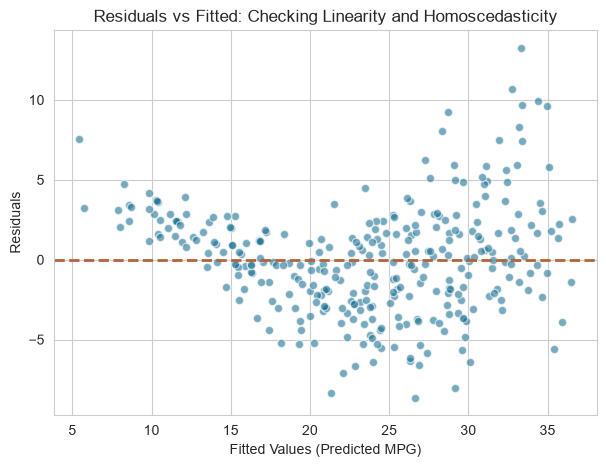

Look for: no curve (linearity) and no funnel/cone shape (homoscedasticity).


In [21]:
plt.figure(figsize=(7, 5))
plt.scatter(y_mpg_train_pred, residuals_train, color="#1C7293", alpha=0.6, edgecolor="white")
plt.axhline(0, color="#B4623A", linestyle="--", linewidth=2)
plt.xlabel("Fitted Values (Predicted MPG)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted: Checking Linearity and Homoscedasticity")
plt.show()

print("Look for: no curve (linearity) and no funnel/cone shape (homoscedasticity).")

#### 2. Normality — Q-Q Plot and the Shapiro-Wilk Test

If the residuals are normally distributed, their Q-Q plot should fall close to the diagonal line.
The Shapiro-Wilk test gives this a precise number.

**Possible values:** the test statistic W ranges from 0 to 1; the p-value ranges from 0 to 1.
**Acceptable result:** p-value > 0.05 (we fail to reject the assumption that residuals are normal).

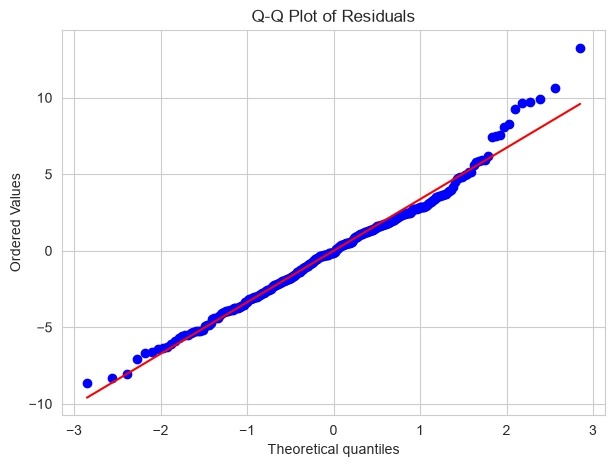

Shapiro-Wilk statistic: 0.984 (range: 0 to 1)
P-value: 0.0012
Acceptable: p-value > 0.05 -> residuals deviate from normal


In [22]:
from scipy import stats

fig = plt.figure(figsize=(7, 5))
stats.probplot(residuals_train, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals_train)
print(f"Shapiro-Wilk statistic: {shapiro_stat:.3f} (range: 0 to 1)")
print(f"P-value: {shapiro_p:.4f}")
print("Acceptable: p-value > 0.05", "-> PASS" if shapiro_p > 0.05 else "-> residuals deviate from normal")

#### 3 & 6. Independence and No Autocorrelation — The Durbin-Watson Test

Both assumptions are checked with the same statistic: independent residuals should show no
autocorrelation from one observation to the next.

**Possible values:** the Durbin-Watson statistic always falls between 0 and 4. Here is how to read
the full range:

| Range | Interpretation |
|---|---|
| 0 to 1.5 | Positive autocorrelation present |
| 1.5 to 2.5 | No significant autocorrelation (acceptable) |
| 2.5 to 4 | Negative autocorrelation present |

**Acceptable result:** a value close to 2, commonly 1.5 to 2.5.

In [23]:
from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(residuals_train)
print(f"Durbin-Watson statistic: {dw_stat:.2f} (range: 0 to 4, no autocorrelation at exactly 2)")
print("Acceptable range: roughly 1.5 to 2.5 ->", "PASS" if 1.5 <= dw_stat <= 2.5 else "investigate further")

Durbin-Watson statistic: 2.17 (range: 0 to 4, no autocorrelation at exactly 2)
Acceptable range: roughly 1.5 to 2.5 -> PASS


#### 5. No Multicollinearity — Variance Inflation Factor (VIF)

VIF measures how much a feature's variance is inflated because it is correlated with the other
features. We compute one VIF value per feature.

**Possible values:** VIF starts at 1, with no fixed upper limit. Here is how to read the full range:

| Range | Interpretation |
|---|---|
| VIF = 1 | No correlation with other predictors |
| 1 < VIF < 5 | Moderate correlation — generally acceptable |
| 5 <= VIF < 10 | High correlation — worth investigating |
| VIF >= 10 | Severe multicollinearity — should be addressed |

**Acceptable result:** VIF < 5 is generally considered fine; some practitioners allow up to 10 before
treating it as a problem.

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame({
    "Feature": X_mpg_train_scaled.columns,
    "VIF": [variance_inflation_factor(X_mpg_train_scaled.values, i) for i in range(X_mpg_train_scaled.shape[1])],
}).sort_values("VIF", ascending=False)

vif_data["Acceptable (VIF < 5)"] = vif_data["VIF"] < 5
vif_data

,Feature,VIF,Acceptable (VIF < 5)
1,displacement,22.807101,False
0,cylinders,11.026066,False
3,weight,10.494946,False
2,horsepower,9.070078,False
7,origin_usa,2.695671,True
4,acceleration,2.494163,True
6,origin_japan,1.831193,True
5,model_year,1.314542,True


With these six checks done, we now know how much to trust the model's coefficients and p-values —
which is exactly what we compute next.

In [25]:
# Evaluate on the test data using RMSE and R-squared.

y_mpg_pred = mpg_model.predict(X_mpg_test_scaled)

rmse = np.sqrt(mean_squared_error(y_mpg_test, y_mpg_pred))
r2 = r2_score(y_mpg_test, y_mpg_pred)

print(f"RMSE: {rmse:.2f} mpg")
print(f"R-squared: {r2:.2f}")

RMSE: 2.89 mpg
R-squared: 0.84


### Does Removing High-VIF Features Change Performance?

The VIF table above flagged a few features with severe multicollinearity. Let's actually remove them
and retrain, to see whether performance changes — rather than just assuming it will.

In [26]:
# Features flagged with VIF >= 5 (moderate-to-severe multicollinearity).

high_vif_features = vif_data[vif_data["VIF"] >= 5]["Feature"].tolist()
low_vif_features = [f for f in X_mpg_train_scaled.columns if f not in high_vif_features]

print("Removing (high VIF):", high_vif_features)
print("Keeping:", low_vif_features)

Removing (high VIF): ['displacement', 'cylinders', 'weight', 'horsepower']
Keeping: ['acceleration', 'model_year', 'origin_japan', 'origin_usa']


In [27]:
# Retrain Linear Regression using only the lower-VIF features.

mpg_model_low_vif = LinearRegression()
mpg_model_low_vif.fit(X_mpg_train_scaled[low_vif_features], y_mpg_train)

y_mpg_pred_low_vif = mpg_model_low_vif.predict(X_mpg_test_scaled[low_vif_features])
rmse_low_vif = np.sqrt(mean_squared_error(y_mpg_test, y_mpg_pred_low_vif))
r2_low_vif = r2_score(y_mpg_test, y_mpg_pred_low_vif)

print(f"RMSE (high-VIF features removed): {rmse_low_vif:.2f} mpg")
print(f"R-squared (high-VIF features removed): {r2_low_vif:.2f}")

RMSE (high-VIF features removed): 4.44 mpg
R-squared (high-VIF features removed): 0.63


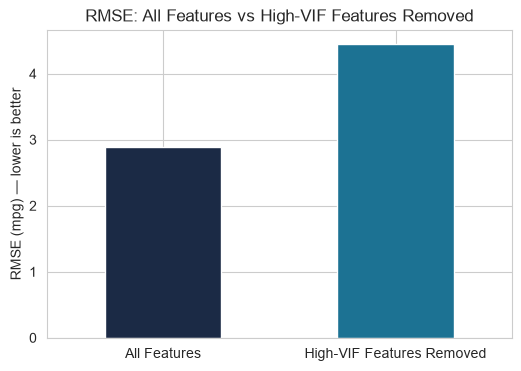

,All Features,High-VIF Features Removed
RMSE,2.887673,4.441569
R-squared,0.844910,0.633088


In [28]:
# Compare before vs after side by side.

vif_comparison = pd.DataFrame({
    "All Features": [rmse, r2],
    "High-VIF Features Removed": [rmse_low_vif, r2_low_vif],
}, index=["RMSE", "R-squared"])

vif_comparison.loc["RMSE"].plot(kind="bar", figsize=(6, 4), color=["#1B2A45", "#1C7293"])
plt.title("RMSE: All Features vs High-VIF Features Removed")
plt.ylabel("RMSE (mpg) — lower is better")
plt.xticks(rotation=0)
plt.show()

vif_comparison

Removing the high-VIF features here actually makes performance noticeably **worse** — RMSE goes up
and R-squared drops. This is an important, realistic lesson: multicollinearity means these features
(engine size, cylinders, weight, horsepower) move together and make individual coefficients hard to
interpret — but collectively they still carry real predictive signal about fuel efficiency. Fixing
multicollinearity is about **trusting individual coefficients**, not a guarantee of better accuracy;
blindly dropping correlated features can throw away genuine information.

A better fix is to keep just **one** representative feature from the correlated group, instead of
dropping all of them, as shown below.

In [29]:
# A smarter fix: keep one representative feature ("weight") from the correlated group,
# instead of dropping all of them.

reduced_features = ["weight", "acceleration", "model_year", "origin_japan", "origin_usa"]

mpg_model_reduced = LinearRegression()
mpg_model_reduced.fit(X_mpg_train_scaled[reduced_features], y_mpg_train)

y_mpg_pred_reduced = mpg_model_reduced.predict(X_mpg_test_scaled[reduced_features])
rmse_reduced = np.sqrt(mean_squared_error(y_mpg_test, y_mpg_pred_reduced))
r2_reduced = r2_score(y_mpg_test, y_mpg_pred_reduced)

print(f"RMSE (all features):                 {rmse:.2f} mpg")
print(f"RMSE (all 4 high-VIF features gone):  {rmse_low_vif:.2f} mpg")
print(f"RMSE (kept 'weight' only):            {rmse_reduced:.2f} mpg")
print()
print("Keeping one representative feature recovers most of the lost performance,")
print("while still resolving the multicollinearity among the dropped features.")

RMSE (all features):                 2.89 mpg
RMSE (all 4 high-VIF features gone):  4.44 mpg
RMSE (kept 'weight' only):            2.95 mpg

Keeping one representative feature recovers most of the lost performance,
while still resolving the multicollinearity among the dropped features.


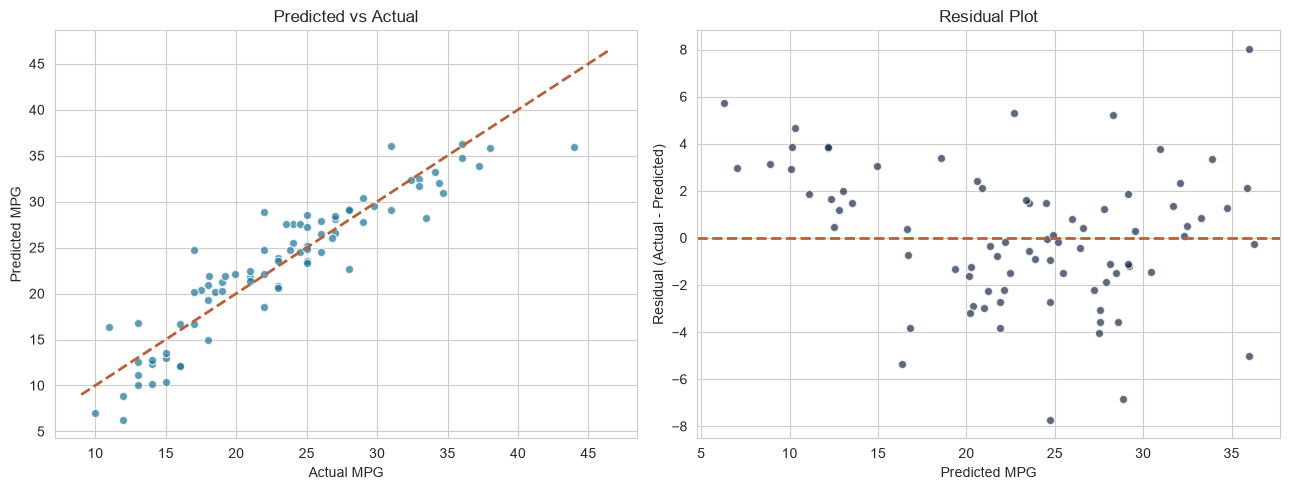

In [30]:
# Visualize predictions: predicted vs actual, and the residuals.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_mpg_test, y_mpg_pred, color="#1C7293", alpha=0.7, edgecolor="white")
min_val, max_val = y_mpg.min(), y_mpg.max()
axes[0].plot([min_val, max_val], [min_val, max_val], color="#B4623A", linestyle="--", linewidth=2)
axes[0].set_xlabel("Actual MPG")
axes[0].set_ylabel("Predicted MPG")
axes[0].set_title("Predicted vs Actual")

residuals = y_mpg_test - y_mpg_pred
axes[1].scatter(y_mpg_pred, residuals, color="#1B2A45", alpha=0.7, edgecolor="white")
axes[1].axhline(0, color="#B4623A", linestyle="--", linewidth=2)
axes[1].set_xlabel("Predicted MPG")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

### Feature Weights and P-Values

`scikit-learn` gives us coefficients, but not their statistical significance. `statsmodels` gives us
both in one summary table, which is the standard tool for this kind of analysis.

In [31]:
# statsmodels needs an explicit constant term added for the intercept.

X_mpg_train_with_const = sm.add_constant(X_mpg_train_scaled)
ols_model = sm.OLS(y_mpg_train.values, X_mpg_train_with_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     174.6
Date:                Thu, 30 Jul 2026   Prob (F-statistic):          7.96e-110
Time:                        22:27:36   Log-Likelihood:                -837.54
No. Observations:                 318   AIC:                             1693.
Df Residuals:                     309   BIC:                             1727.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           23.6082      0.192    123.153   

### 📊 OLS Regression Summary (Quick Interpretation)

#### 1. Model Information

| Metric | Value | Interpretation |
|---------|------:|---------------|
| **Model** | OLS | Ordinary Least Squares Linear Regression |
| **Dependent Variable** | y (MPG) | Target variable being predicted |
| **Observations** | 318 | Number of data samples used |
| **Predictors** | 8 | Number of independent variables |


#### 2. Model Performance

| Metric | Value | Interpretation |
|---------|------:|---------------|
| **R²** | **0.819** | The model explains **81.9%** of the variation in MPG. |
| **Adjusted R²** | **0.814** | Similar to R², indicating most predictors are useful. |
| **F-statistic** | **174.6** | Measures whether the overall regression model is significant. |
| **Prob (F-statistic)** | **7.96 × 10⁻¹¹⁰** | Very small p-value (<0.05), so the overall model is statistically significant. |


#### 3. Coefficient Interpretation

| Feature | Coefficient | P-value | Significant? | Interpretation |
|---------|------------:|---------:|:------------:|---------------|
| **Intercept (const)** | 23.61 | <0.001 | ✅ | Baseline predicted MPG when all predictors are 0. |
| **Cylinders** | -0.279 | 0.662 | ❌ | No significant impact on MPG. |
| **Displacement** | 2.033 | 0.027 | ✅ | Significant positive relationship with MPG in this model. |
| **Horsepower** | -0.539 | 0.351 | ❌ | Not statistically significant. |
| **Weight** | -5.915 | <0.001 | ✅ | Heavier cars generally have lower MPG. |
| **Acceleration** | 0.188 | 0.536 | ❌ | Not statistically significant. |
| **Model Year** | 2.971 | <0.001 | ✅ | Newer cars tend to have higher MPG. |
| **Origin (Japan)** | -0.112 | 0.667 | ❌ | No significant difference from the reference origin. |
| **Origin (USA)** | -1.433 | <0.001 | ✅ | USA cars have lower MPG than the reference origin. |


#### 4. How to Read the Coefficients

- **Positive coefficient (+)** → As the feature increases, the predicted MPG increases.
- **Negative coefficient (-)** → As the feature increases, the predicted MPG decreases.
- **Large absolute coefficient** → Stronger influence on the prediction.
- **Small coefficient** → Weaker influence.


#### 5. P-value Interpretation

| P-value | Decision |
|----------|----------|
| **< 0.05** | ✅ Feature is statistically significant. |
| **≥ 0.05** | ❌ Feature is not statistically significant. |


#### 6. Confidence Interval (95%)

- Shows the likely range of the true coefficient.
- If the interval **contains 0**, the feature is usually **not significant**.
- If the interval **does not contain 0**, the feature is considered **significant**.


#### 7. Residual Diagnostics

| Metric | Value | Interpretation |
|---------|------:|---------------|
| **Durbin-Watson** | 2.172 | Close to 2, indicating little evidence of autocorrelation. |
| **Omnibus p-value** | 0.000 | Residuals are not perfectly normally distributed. |
| **Jarque-Bera p-value** | 2.96e-05 | Residuals deviate from normality. |
| **Skew** | 0.417 | Residuals are slightly right-skewed. |
| **Kurtosis** | 3.937 | Residuals have slightly heavier tails than a normal distribution. |
| **Condition Number** | 12.3 | Low value, suggesting no major multicollinearity issues. |


#### 8. Overall Conclusions

✅ The regression model performs well (**R² = 81.9%**).

✅ The overall model is highly significant (**F-test p-value < 0.001**).

✅ Significant predictors:
- Weight
- Model Year
- Displacement
- Origin (USA)

❌ Not significant predictors:
- Cylinders
- Horsepower
- Acceleration
- Origin (Japan)

✅ Heavier vehicles generally have **lower MPG**.

✅ Newer vehicles generally have **higher MPG**.

✅ The residuals show slight departures from normality, but there is **no strong evidence of autocorrelation or multicollinearity**.

---
#### 📌 Key Takeaways

- **R²** → How well the model explains the target variable.
- **Adjusted R²** → R² adjusted for the number of predictors.
- **Coefficient** → Direction and magnitude of a feature's effect.
- **P-value** → Determines whether a feature is statistically significant.
- **F-statistic** → Tests whether the overall regression model is significant.
- **Confidence Interval** → Likely range of the true coefficient value.
- **Durbin-Watson** → Detects autocorrelation in residuals.
- **Condition Number** → Detects multicollinearity among predictors.
---

In [32]:
# Pull out just the coefficient and p-value columns as a clean, sorted table.

weights_table = pd.DataFrame({
    "Coefficient": ols_model.params,
    "P-Value": ols_model.pvalues,
})
weights_table["Significant (p < 0.05)"] = weights_table["P-Value"] < 0.05
weights_table.sort_values("P-Value")

,Coefficient,P-Value,Significant (p < 0.05)
const,23.608176,1.145332e-264,True
model_year,2.971431,4.893881e-33,True
weight,-5.914735,5.046995e-19,True
origin_usa,-1.433003,7.617137e-06,True
displacement,2.033373,2.707027e-02,True
horsepower,-0.539182,3.510719e-01,False
acceleration,0.187514,5.361256e-01,False
cylinders,-0.278695,6.618183e-01,False
origin_japan,-0.111843,6.666633e-01,False


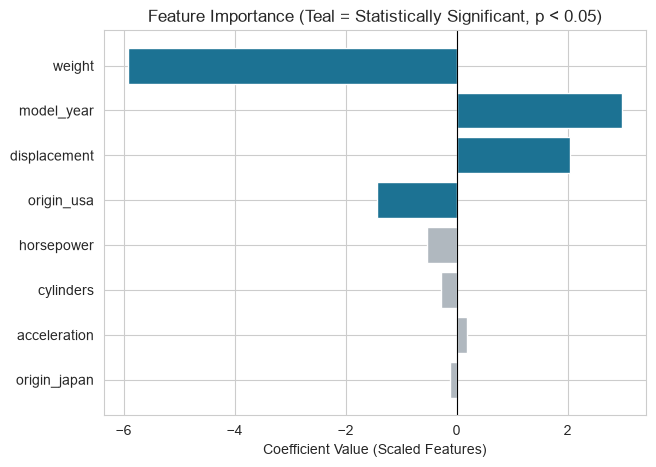

In [33]:
# Visualize feature importance using the coefficient magnitudes, colored by significance.

plot_data = weights_table.drop("const").sort_values("Coefficient", key=abs)
colors = ["#1C7293" if sig else "#B0B8BF" for sig in plot_data["Significant (p < 0.05)"]]

plt.figure(figsize=(7, 5))
plt.barh(plot_data.index, plot_data["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Importance (Teal = Statistically Significant, p < 0.05)")
plt.xlabel("Coefficient Value (Scaled Features)")
plt.show()

### Does Removing Insignificant Features (p > 0.05) Change Performance?

The gray bars above (p > 0.05) are features the model could not confidently distinguish from having
no effect at all. Let's remove them and retrain, to see the actual impact.

In [34]:
# Features with p-value > 0.05 are statistically insignificant.

insignificant_features = weights_table[
    (weights_table["P-Value"] > 0.05) & (weights_table.index != "const")
].index.tolist()
significant_features = [f for f in X_mpg_train_scaled.columns if f not in insignificant_features]

print("Removing (insignificant, p > 0.05):", insignificant_features)
print("Keeping (significant, p <= 0.05):", significant_features)

Removing (insignificant, p > 0.05): ['cylinders', 'horsepower', 'acceleration', 'origin_japan']
Keeping (significant, p <= 0.05): ['displacement', 'weight', 'model_year', 'origin_usa']


In [35]:
# Retrain Linear Regression using only the statistically significant features.

mpg_model_significant = LinearRegression()
mpg_model_significant.fit(X_mpg_train_scaled[significant_features], y_mpg_train)

y_mpg_pred_significant = mpg_model_significant.predict(X_mpg_test_scaled[significant_features])
rmse_significant = np.sqrt(mean_squared_error(y_mpg_test, y_mpg_pred_significant))
r2_significant = r2_score(y_mpg_test, y_mpg_pred_significant)

print(f"RMSE (insignificant features removed): {rmse_significant:.2f} mpg")
print(f"R-squared (insignificant features removed): {r2_significant:.2f}")

RMSE (insignificant features removed): 2.93 mpg
R-squared (insignificant features removed): 0.84


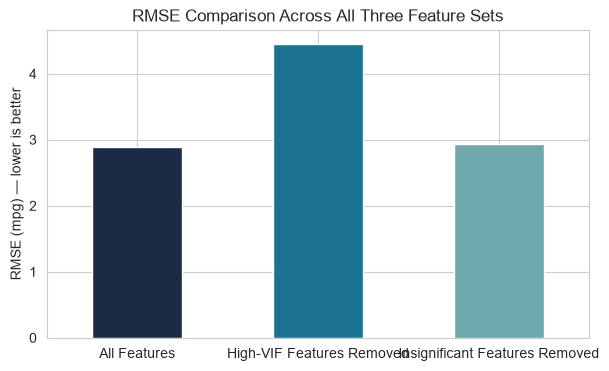

,All Features,High-VIF Features Removed,Insignificant Features Removed
RMSE,2.887673,4.441569,2.927093
R-squared,0.844910,0.633088,0.840646


In [36]:
# Compare all three versions of the model side by side.

full_comparison = pd.DataFrame({
    "All Features": [rmse, r2],
    "High-VIF Features Removed": [rmse_low_vif, r2_low_vif],
    "Insignificant Features Removed": [rmse_significant, r2_significant],
}, index=["RMSE", "R-squared"])

full_comparison.loc["RMSE"].plot(kind="bar", figsize=(7, 4), color=["#1B2A45", "#1C7293", "#6FA8AD"])
plt.title("RMSE Comparison Across All Three Feature Sets")
plt.ylabel("RMSE (mpg) — lower is better")
plt.xticks(rotation=0)
plt.show()

full_comparison

Dropping the statistically insignificant features also leaves performance essentially unchanged —
which is exactly what the p-values predicted: those features were not contributing meaningfully to
begin with. The payoff of removing them is a **simpler, more interpretable model** with the same
predictive power, not necessarily a lower error.

### Prediction Function

Instead of a `Pipeline` object, we write a small, explicit function that applies the same steps
(fill defaults, encode, scale, predict) to a brand-new car's specifications.

In [37]:
def predict_mpg(new_car: dict) -> float:
    """Predict MPG for a new car, given its raw specifications as a dictionary."""
    row = pd.DataFrame([new_car])

    # Recreate the same one-hot encoding used during training.
    row = pd.get_dummies(row, columns=["origin"], drop_first=True)
    for col in origin_cols:
        if col not in row.columns:
            row[col] = 0
    row = row[X_mpg_train.columns]  # ensure identical column order

    # Apply the SAME scaler fitted on the training data (never re-fit on new data).
    row_scaled = pd.DataFrame(scaler_mpg.transform(row), columns=row.columns)

    return mpg_model.predict(row_scaled)[0]

# Try it on a new car.
sample_car = {
    "cylinders": 4, "displacement": 140, "horsepower": 90,
    "weight": 2400, "acceleration": 16.5, "model_year": 80, "origin": "usa",
}
print(f"Predicted MPG: {predict_mpg(sample_car):.1f}")

Predicted MPG: 32.2


In [38]:
# Save the scaler and model so they can be reused later without retraining.

joblib.dump(scaler_mpg, "models/mpg_scaler.joblib")
joblib.dump(mpg_model, "models/linear_regression_model.joblib")
print("Saved: models/mpg_scaler.joblib")
print("Saved: models/linear_regression_model.joblib")

Saved: models/mpg_scaler.joblib
Saved: models/linear_regression_model.joblib



---

## Practical 3: Logistic Regression

### Step A: A Simple Toy Example First

A 10-record dataset: hours studied, and whether the student passed. Small enough to reason about by hand.

In [39]:
# A small, fully visible dataset: study hours -> pass (1) or fail (0).

toy_hours = np.array([[1], [2], [2.5], [3], [4], [5], [5.5], [6], [7], [8]])
toy_pass = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

toy_logreg = LogisticRegression()
toy_logreg.fit(toy_hours, toy_pass)

print("Coefficient (w):", toy_logreg.coef_[0][0])
print("Intercept (b):", toy_logreg.intercept_[0])
print()

# Predict probability of passing for a few new study-hour values.
for hours in [2, 4, 4.5, 5, 9]:
    proba = toy_logreg.predict_proba([[hours]])[0][1]
    prediction = toy_logreg.predict([[hours]])[0]
    print(f"{hours} hours studied -> P(pass) = {proba:.2f} -> predicted: {'Pass' if prediction == 1 else 'Fail'}")

Coefficient (w): 1.3114683669623763
Intercept (b): -5.754482832650984

2 hours studied -> P(pass) = 0.04 -> predicted: Fail
4 hours studied -> P(pass) = 0.38 -> predicted: Fail
4.5 hours studied -> P(pass) = 0.54 -> predicted: Pass
5 hours studied -> P(pass) = 0.69 -> predicted: Pass
9 hours studied -> P(pass) = 1.00 -> predicted: Pass


Notice how the predicted probability rises smoothly with study hours, and crosses 0.5 somewhere
between 4 and 5 hours — exactly where our toy data starts flipping from fail to pass.

### Step B: The Real Practical — Titanic Dataset

We reuse the Titanic data already prepared and split in Practical 1.

In [40]:
# Fit Logistic Regression directly on the already-scaled, already-split Titanic data.

logreg_model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
logreg_model.fit(X_titanic_train, y_titanic_train)

logreg_predictions = logreg_model.predict(X_titanic_test)
print("Logistic Regression trained successfully.")

# ------------------------------------------------------------------
# For reference — since Practical 1 already scaled the data before
# splitting, there is no separate scaling step to fold into a Pipeline
# here. If you scaled AFTER splitting instead (as in Practical 2), the
# equivalent Pipeline would look like:
#
# from sklearn.pipeline import Pipeline
# titanic_pipeline = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", LogisticRegression(max_iter=5000)),
# ])
# titanic_pipeline.fit(X_titanic_train_raw, y_titanic_train)
# ------------------------------------------------------------------

Logistic Regression trained successfully.


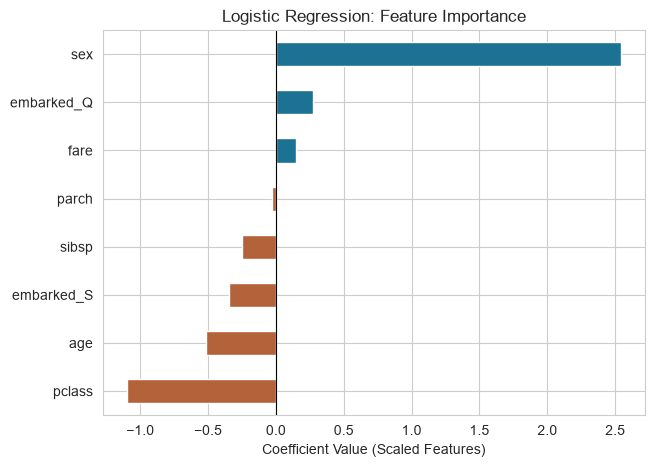

Teal bars increase survival odds; orange bars decrease them.


In [41]:
# Feature importance: the model's coefficients.

logreg_importance = pd.Series(logreg_model.coef_[0], index=X_titanic_train.columns).sort_values()

colors = ["#1C7293" if v > 0 else "#B4623A" for v in logreg_importance.values]

plt.figure(figsize=(7, 5))
logreg_importance.plot(kind="barh", color=colors)
plt.title("Logistic Regression: Feature Importance")
plt.xlabel("Coefficient Value (Scaled Features)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

print("Teal bars increase survival odds; orange bars decrease them.")

In [42]:
# Evaluate using classification metrics.

logreg_accuracy = accuracy_score(y_titanic_test, logreg_predictions)
logreg_precision = precision_score(y_titanic_test, logreg_predictions)
logreg_recall = recall_score(y_titanic_test, logreg_predictions)
logreg_f1 = f1_score(y_titanic_test, logreg_predictions)

print(f"Accuracy:  {logreg_accuracy:.2f}")
print(f"Precision: {logreg_precision:.2f}")
print(f"Recall:    {logreg_recall:.2f}")
print(f"F1 Score:  {logreg_f1:.2f}")

Accuracy:  0.78
Precision: 0.72
Recall:    0.69
F1 Score:  0.70


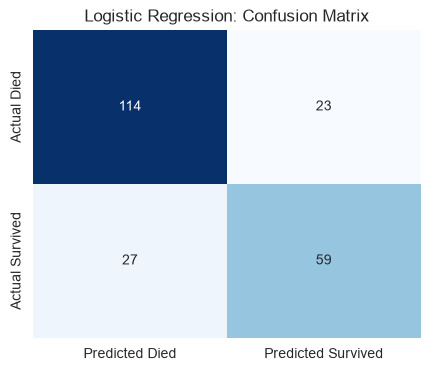

In [43]:
# Confusion matrix.

cm = confusion_matrix(y_titanic_test, logreg_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Died", "Predicted Survived"],
            yticklabels=["Actual Died", "Actual Survived"])
plt.title("Logistic Regression: Confusion Matrix")
plt.show()

In [44]:
# Save the trained model.

joblib.dump(logreg_model, "models/logistic_regression_model.joblib")
print("Saved: models/logistic_regression_model.joblib")

Saved: models/logistic_regression_model.joblib



---

## Practical 4: K-Nearest Neighbors (KNN)

### Step A: A Simple Toy Example First

A handful of 2D points from two classes. We will literally print out which neighbors get picked for
a new point, so the "vote" mechanism is completely visible.

In [45]:
from sklearn.neighbors import KNeighborsClassifier

# A small 2D toy dataset: two visually separate groups of points.
toy_points = np.array([
    [1, 1], [1, 2], [2, 1], [2, 2],       # Class 0 (bottom-left cluster)
    [8, 8], [8, 9], [9, 8], [9, 9],       # Class 1 (top-right cluster)
])
toy_labels = np.array([0, 0, 0, 0, 1, 1, 1, 1])

toy_knn = KNeighborsClassifier(n_neighbors=3)
toy_knn.fit(toy_points, toy_labels)

# A new point closer to the bottom-left cluster.
new_point = np.array([[2.5, 2.5]])

distances, neighbor_indices = toy_knn.kneighbors(new_point)
print("Distances to the 3 nearest neighbors:", np.round(distances[0], 2))
print("Those neighbors' coordinates:\n", toy_points[neighbor_indices[0]])
print("Those neighbors' labels:", toy_labels[neighbor_indices[0]])
print()
print("Predicted class for new point:", toy_knn.predict(new_point)[0])

Distances to the 3 nearest neighbors: [0.71 1.58 1.58]
Those neighbors' coordinates:
 [[2 2]
 [2 1]
 [1 2]]
Those neighbors' labels: [0 0 0]

Predicted class for new point: 0


All 3 nearest neighbors belong to Class 0, so the new point is classified as Class 0 — a unanimous
vote. This is exactly the same mechanism used below, just with more neighbors and more features.

### Step B: The Real Practical — Titanic Dataset

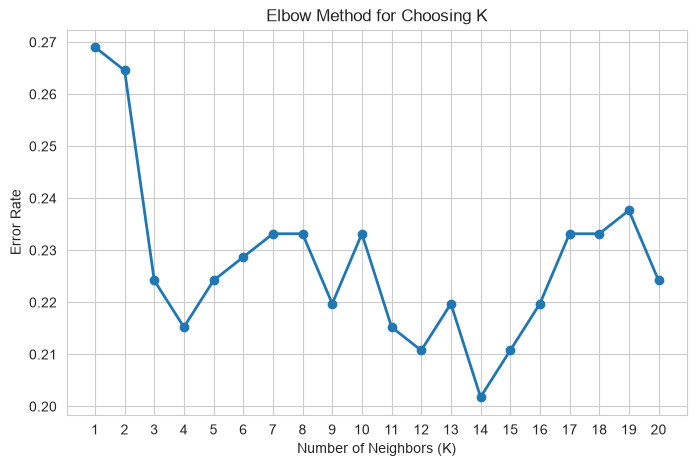

Best K: 14
Minimum Error Rate: 0.2018


In [12]:
# Elbow Method for Selecting K

from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

error_rate = []

# Try K values from 1 to 20
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_titanic_train, y_titanic_train)

    y_pred = knn.predict(X_titanic_test)

    # Calculate error rate
    error = (y_pred != y_titanic_test).mean()
    error_rate.append(error)

# Plot Error Rate vs K
plt.figure(figsize=(8,5))
plt.plot(k_range, error_rate, marker='o', linewidth=2)
plt.title("Elbow Method for Choosing K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error Rate")
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Best K (Minimum Error)
best_k = k_range[error_rate.index(min(error_rate))]
print(f"Best K: {best_k}")
print(f"Minimum Error Rate: {min(error_rate):.4f}")

In [16]:
# Fit KNN directly on the already-scaled, already-split Titanic data.

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_titanic_train, y_titanic_train)

knn_predictions = knn_model.predict(X_titanic_test)
print(f"KNN trained successfully with K = {best_k}.")

KNN trained successfully with K = 14.


In [17]:
# Evaluate using classification metrics.

knn_accuracy = accuracy_score(y_titanic_test, knn_predictions)
knn_precision = precision_score(y_titanic_test, knn_predictions)
knn_recall = recall_score(y_titanic_test, knn_predictions)
knn_f1 = f1_score(y_titanic_test, knn_predictions)

print(f"Accuracy:  {knn_accuracy:.2f}")
print(f"Precision: {knn_precision:.2f}")
print(f"Recall:    {knn_recall:.2f}")
print(f"F1 Score:  {knn_f1:.2f}")

Accuracy:  0.78
Precision: 0.80
Recall:    0.59
F1 Score:  0.68


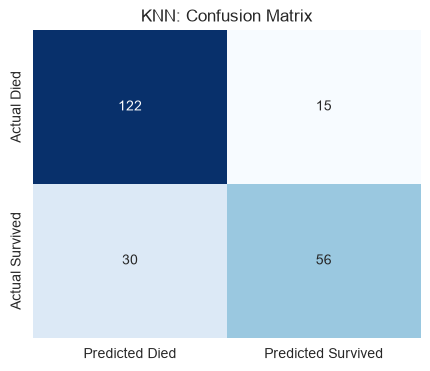

In [15]:
# Confusion matrix.

cm = confusion_matrix(y_titanic_test, knn_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Died", "Predicted Survived"],
            yticklabels=["Actual Died", "Actual Survived"])
plt.title("KNN: Confusion Matrix")
plt.show()

### Feature Importance for KNN

KNN has no coefficients to read, since it does not fit a formula. Instead, we use **Permutation
Importance**: shuffle one feature's values at a time and see how much the model's accuracy drops.
A feature that matters a lot will hurt accuracy badly when shuffled; an unimportant one barely
changes anything.

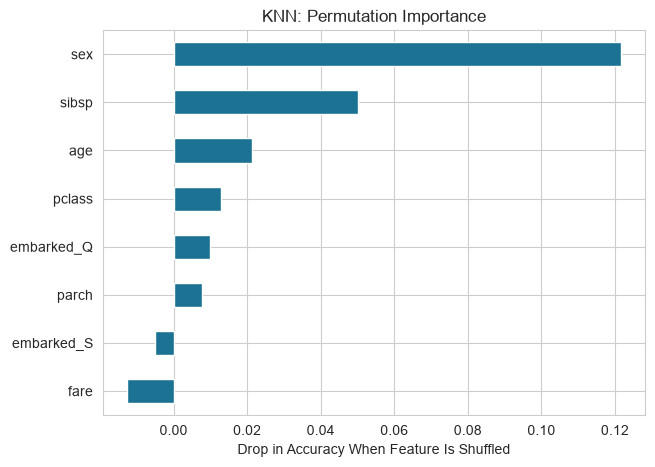

In [50]:
perm_result = permutation_importance(
    knn_model, X_titanic_test, y_titanic_test, n_repeats=20, random_state=RANDOM_STATE
)

knn_importance = pd.Series(perm_result.importances_mean, index=X_titanic_test.columns).sort_values()

plt.figure(figsize=(7, 5))
knn_importance.plot(kind="barh", color="#1C7293")
plt.title("KNN: Permutation Importance")
plt.xlabel("Drop in Accuracy When Feature Is Shuffled")
plt.show()

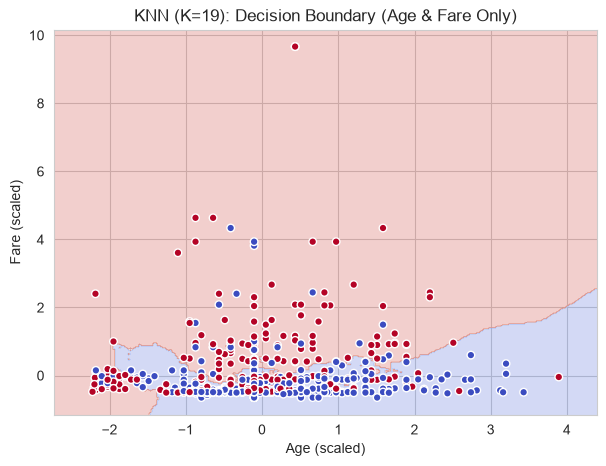

In [51]:
# Visualize KNN's decision boundary using 2 features, purely for illustration.
# This is a separate, simplified model trained on just "age" and "fare" so the boundary can be plotted.

two_feature_cols = ["age", "fare"]
X_vis_train = X_titanic_train[two_feature_cols]

vis_knn = KNeighborsClassifier(n_neighbors=best_k)
vis_knn.fit(X_vis_train, y_titanic_train)

x_min, x_max = X_vis_train.iloc[:, 0].min() - 0.5, X_vis_train.iloc[:, 0].max() + 0.5
y_min, y_max = X_vis_train.iloc[:, 1].min() - 0.5, X_vis_train.iloc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=two_feature_cols)
grid_predictions = vis_knn.predict(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, grid_predictions, alpha=0.25, cmap="coolwarm")
plt.scatter(X_vis_train.iloc[:, 0], X_vis_train.iloc[:, 1], c=y_titanic_train, cmap="coolwarm", edgecolor="white", s=30)
plt.xlabel("Age (scaled)")
plt.ylabel("Fare (scaled)")
plt.title(f"KNN (K={best_k}): Decision Boundary (Age & Fare Only)")
plt.show()

In [52]:
# Save the trained model.

joblib.dump(knn_model, "models/knn_model.joblib")
print("Saved: models/knn_model.joblib")

Saved: models/knn_model.joblib



---

## Practical 5: Support Vector Machine (SVM)

### Step A: A Simple Toy Example First

A small, clearly-separable 2D dataset. We fit a linear-kernel SVM and look directly at which points
became the support vectors — the only points that actually decide where the boundary sits.

In [53]:
from sklearn.svm import SVC

# A small, linearly separable 2D toy dataset.
toy_X = np.array([
    [1, 2], [2, 1], [2, 3], [3, 2],         # Class 0
    [6, 7], [7, 6], [7, 8], [8, 7],         # Class 1
])
toy_y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

toy_svm = SVC(kernel="linear", C=1.0)
toy_svm.fit(toy_X, toy_y)

print("Support vectors (the points that define the margin):")
print(toy_svm.support_vectors_)
print()
print("Number of support vectors per class:", toy_svm.n_support_)

Support vectors (the points that define the margin):
[[3. 2.]
 [7. 6.]]

Number of support vectors per class: [1 1]


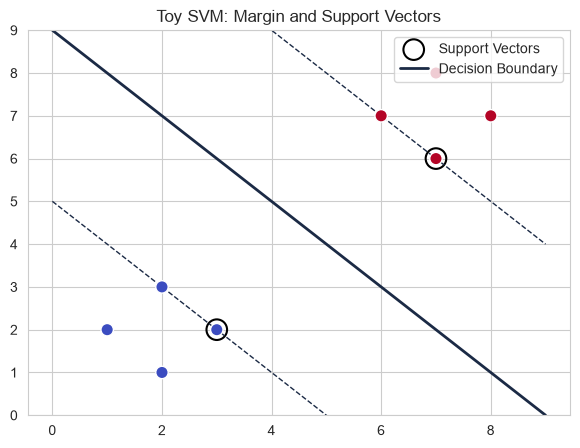

In [54]:
# Visualize the toy example's margin and support vectors.

xx_toy = np.linspace(0, 9, 200)
w = toy_svm.coef_[0]
b = toy_svm.intercept_[0]
yy_boundary = -(w[0] * xx_toy + b) / w[1]
margin = 1 / np.sqrt(np.sum(w ** 2))
yy_up = yy_boundary + margin * np.sqrt(1 + (w[0] / w[1]) ** 2)
yy_down = yy_boundary - margin * np.sqrt(1 + (w[0] / w[1]) ** 2)

plt.figure(figsize=(7, 5))
plt.scatter(toy_X[:, 0], toy_X[:, 1], c=toy_y, cmap="coolwarm", s=80, edgecolor="white", zorder=3)
plt.scatter(toy_svm.support_vectors_[:, 0], toy_svm.support_vectors_[:, 1],
            facecolors="none", edgecolors="black", s=220, linewidth=1.5, label="Support Vectors", zorder=2)
plt.plot(xx_toy, yy_boundary, color="#1B2A45", linewidth=2, label="Decision Boundary")
plt.plot(xx_toy, yy_up, color="#1B2A45", linestyle="--", linewidth=1)
plt.plot(xx_toy, yy_down, color="#1B2A45", linestyle="--", linewidth=1)
plt.ylim(0, 9)
plt.title("Toy SVM: Margin and Support Vectors")
plt.legend()
plt.show()

Only 2 points per class (the ones closest to the boundary) became support vectors — every other
point could be moved or removed without changing the boundary at all.

### Step B: The Real Practical — Titanic Dataset

In [55]:
# Fit a linear-kernel SVM directly on the already-scaled, already-split Titanic data.
# probability=True lets us compare predicted probabilities with the other models later.

svm_model = SVC(kernel="linear", probability=True, random_state=RANDOM_STATE)
svm_model.fit(X_titanic_train, y_titanic_train)

svm_predictions = svm_model.predict(X_titanic_test)
print("SVM trained successfully.")
print("Number of support vectors:", svm_model.n_support_.sum())

SVM trained successfully.
Number of support vectors: 318


C:\Shridhar\Study\Upgrad\Live Sessions\IIT KGP C2 - Foundation Session Details\5. Basic Machine Learning - I\Demo\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


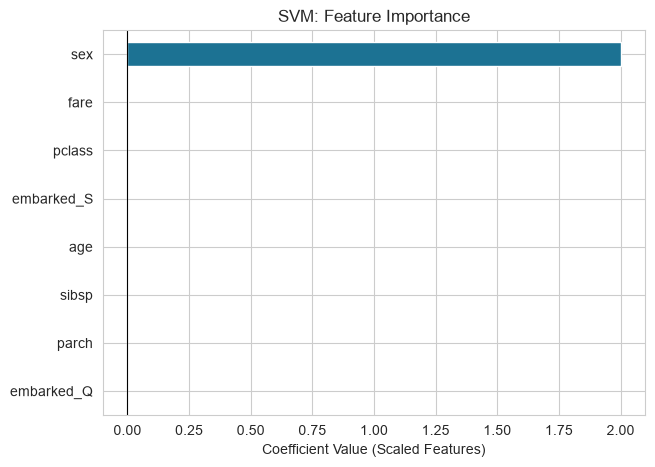

In [56]:
# Feature importance: for a linear kernel, the coefficients work just like Logistic Regression's.

svm_importance = pd.Series(svm_model.coef_[0], index=X_titanic_train.columns).sort_values()

colors = ["#1C7293" if v > 0 else "#B4623A" for v in svm_importance.values]

plt.figure(figsize=(7, 5))
svm_importance.plot(kind="barh", color=colors)
plt.title("SVM: Feature Importance")
plt.xlabel("Coefficient Value (Scaled Features)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

In [57]:
# Evaluate using classification metrics.

svm_accuracy = accuracy_score(y_titanic_test, svm_predictions)
svm_precision = precision_score(y_titanic_test, svm_predictions)
svm_recall = recall_score(y_titanic_test, svm_predictions)
svm_f1 = f1_score(y_titanic_test, svm_predictions)

print(f"Accuracy:  {svm_accuracy:.2f}")
print(f"Precision: {svm_precision:.2f}")
print(f"Recall:    {svm_recall:.2f}")
print(f"F1 Score:  {svm_f1:.2f}")

Accuracy:  0.77
Precision: 0.71
Recall:    0.66
F1 Score:  0.69


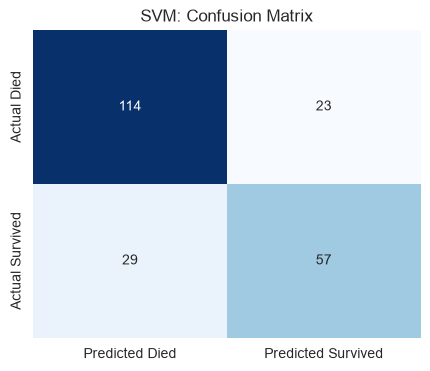

In [58]:
# Confusion matrix.

cm = confusion_matrix(y_titanic_test, svm_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Died", "Predicted Survived"],
            yticklabels=["Actual Died", "Actual Survived"])
plt.title("SVM: Confusion Matrix")
plt.show()

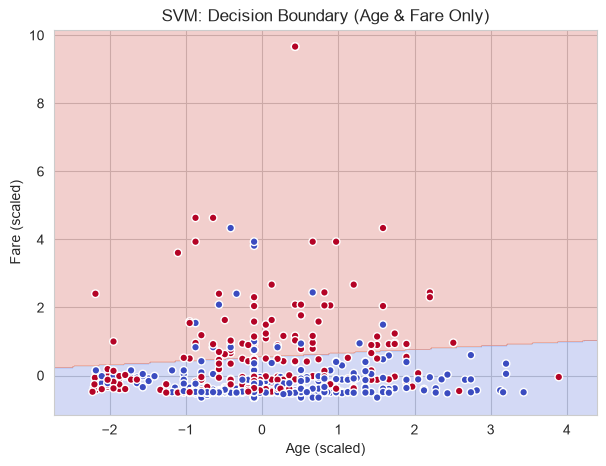

In [59]:
# Visualize SVM's decision boundary using the same 2 features as the KNN example above.

vis_svm = SVC(kernel="linear", random_state=RANDOM_STATE)
vis_svm.fit(X_vis_train, y_titanic_train)

grid_predictions_svm = vis_svm.predict(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, grid_predictions_svm, alpha=0.25, cmap="coolwarm")
plt.scatter(X_vis_train.iloc[:, 0], X_vis_train.iloc[:, 1], c=y_titanic_train, cmap="coolwarm", edgecolor="white", s=30)
plt.xlabel("Age (scaled)")
plt.ylabel("Fare (scaled)")
plt.title("SVM: Decision Boundary (Age & Fare Only)")
plt.show()

In [60]:
# Save the trained model.

joblib.dump(svm_model, "models/svm_model.joblib")
print("Saved: models/svm_model.joblib")

Saved: models/svm_model.joblib


### Final Comparison: Logistic Regression vs KNN vs SVM

All three classifiers were trained and evaluated on the exact same Titanic train-test split, so this
comparison is a fair, apples-to-apples look at how they stack up.

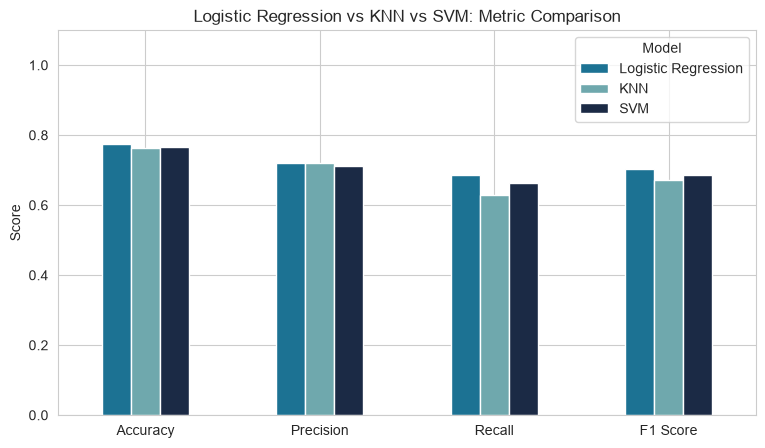

,Logistic Regression,KNN,SVM
Accuracy,0.775785,0.762332,0.766816
Precision,0.719512,0.720000,0.712500
Recall,0.686047,0.627907,0.662791
F1 Score,0.702381,0.670807,0.686747


In [61]:
comparison = pd.DataFrame({
    "Logistic Regression": [logreg_accuracy, logreg_precision, logreg_recall, logreg_f1],
    "KNN": [knn_accuracy, knn_precision, knn_recall, knn_f1],
    "SVM": [svm_accuracy, svm_precision, svm_recall, svm_f1],
}, index=["Accuracy", "Precision", "Recall", "F1 Score"])

comparison.plot(kind="bar", figsize=(9, 5), color=["#1C7293", "#6FA8AD", "#1B2A45"])
plt.title("Logistic Regression vs KNN vs SVM: Metric Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()

comparison

---

## Summary

In this notebook, we worked through the full machine learning workflow using two real datasets:

- **Titanic dataset** — cleaned and prepared from scratch (missing values, encoding, EDA, scaling,
  splitting), then used to train and compare Logistic Regression, KNN, and SVM
- **Auto MPG dataset** — cleaned and prepared, then used to train a Linear Regression model,
  complete with a statistically-grounded feature-weight table (coefficients and p-values)

For Linear Regression, Logistic Regression, KNN, and SVM, we started with a small, fully-visible toy
example before moving to the real data, so the core mechanics of each algorithm were clear first.

Every step was written out explicitly rather than hidden inside a `Pipeline`, with the `Pipeline`
equivalent shown in comments for reference. Every trained model was saved with `joblib` for reuse.

These are the foundational building blocks for the more advanced models covered in
**Basic Machine Learning - II** (Decision Trees, Random Forest, Clustering, and more).